In [ ]:
import torch

import numpy as np
import math

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.cm import get_cmap

import copy
import seaborn as sns

import tqdm
import pickle

# MI estimators
# from utils.estimators import *

In [6]:
def import_data(num_policy:int , case:str, level_list:list):
    dataset = {}
    for level in level_list:
        for policy in range(num_policy):
            dataset[level] = (np.load(f"../data/cpg_rbf_hebb/{case}-ALPHA{level}-{policy}.npy" , allow_pickle=True).item())
    return dataset

In [48]:
NUM_POLICY = 1
level_list = [0.1 , 0.2 ,0.3 , 0.5 ,0.6 , 0.7]

normal= import_data(num_policy=NUM_POLICY, case="normal", level_list=level_list)
loss = import_data(num_policy=NUM_POLICY, case="loss", level_list=level_list)
morph = import_data(num_policy=NUM_POLICY, case="morph", level_list=level_list)
cases = ["normal" , "loss" , "morph"]

# [case:str][number_file:int][data/brain:str]

In [49]:
performance = {case : [] for case in cases}
for level in level_list:
    performance["normal"].append(np.max(normal[level]["data"]["pos_x"][:,0]))
    performance["loss"].append(np.max(loss[level]["data"]["pos_x"][:,0]))

data key
'state', 'action', 'action_lowpass', 'pos_x', 'pos_y', 'yaw', 'fc', 'torque', 'reward', 'vel_w', 'vel_b', 'cpg', 'post_rbf', 'hebb_action', 'dof_pos', 'dof_pos_scaled', 'action_scaled'

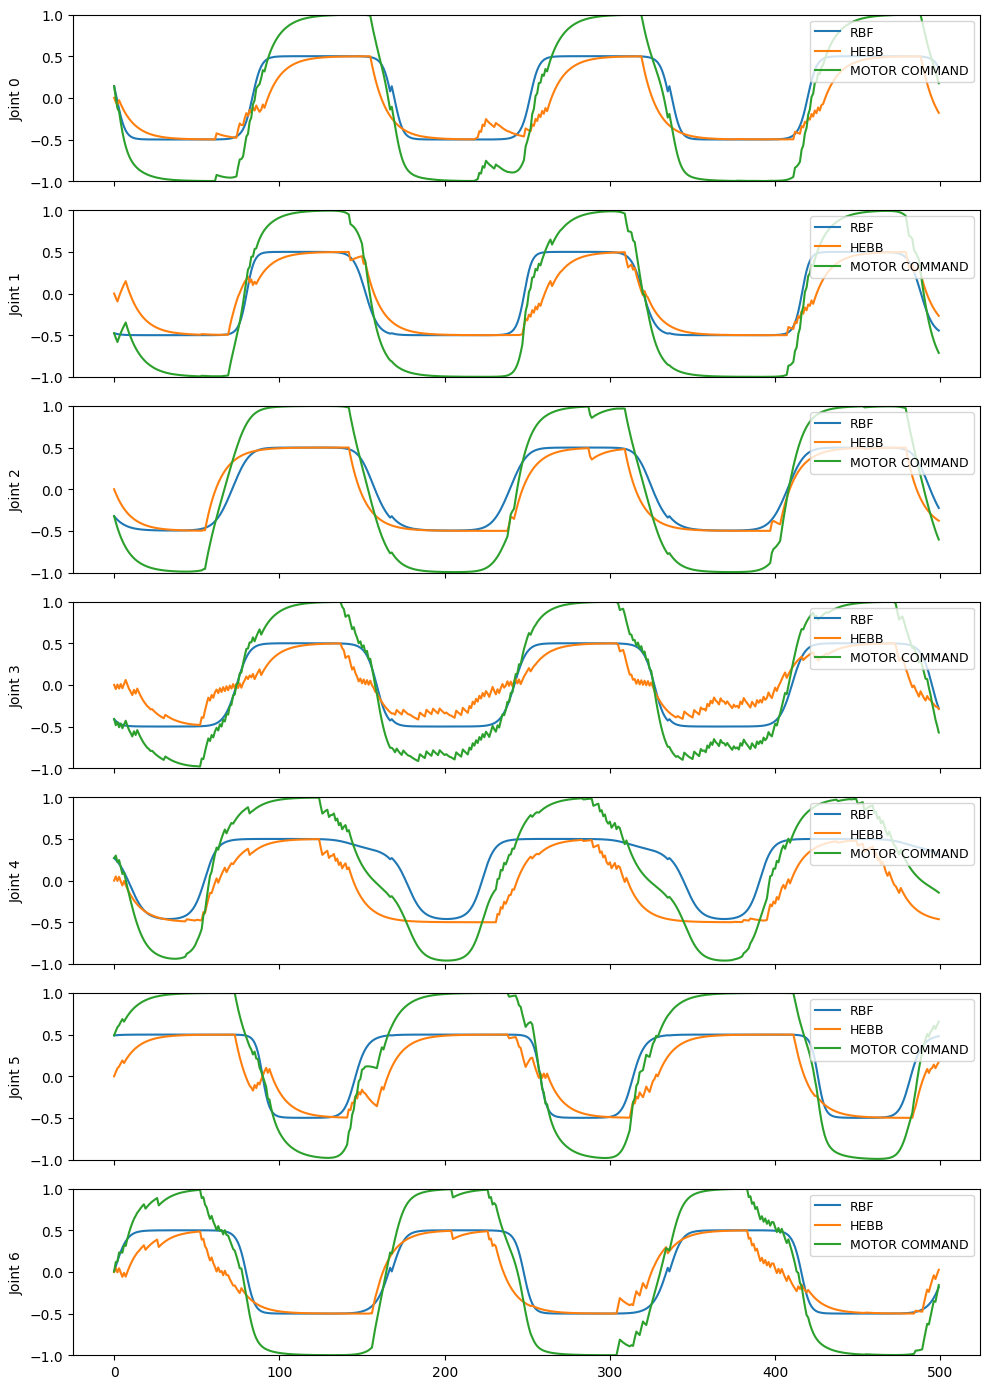

In [56]:
data = morph

n = 7
level = 0.5

fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(10, 2*n), sharex=True)


for i in range(n):
    w = data[level]["data"]["state"][:,0,i]
    x = data[level]["data"]["post_rbf"][:,0,i]
    y = data[level]["data"]["hebb_action"][:,0,i]
    z = data[level]["data"]["action"][:,0,i]

    # axes[i].plot(w , label="state")
    axes[i].plot(x , label="RBF")
    axes[i].plot(y , label="HEBB")
    axes[i].plot(z , label="MOTOR COMMAND")
    axes[i].set_ylabel(f"Joint {i}")
    axes[i].set_ylim(-1,1)

    axes[i].legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()
